## Log TransFormation

In [41]:
import pandas as pd
import numpy as np

import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [62]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [63]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [64]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [71]:
df['Age']=df['Age'].fillna(df['Age'].mean())

In [72]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Age       891 non-null    float64
 2   Fare      891 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 21.0 KB


In [73]:
X = df.iloc[:,1:3]
y = df.iloc[:,0]

In [74]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [75]:
X

,Age,Fare
0,22.000000,7.2500
1,38.000000,71.2833
2,26.000000,7.9250
3,35.000000,53.1000
4,35.000000,8.0500
...,...,...
886,27.000000,13.0000
887,19.000000,30.0000
888,29.699118,23.4500
889,26.000000,30.0000


C:\Users\msi 1\AppData\Local\Temp\ipykernel_21172\2888751792.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'])


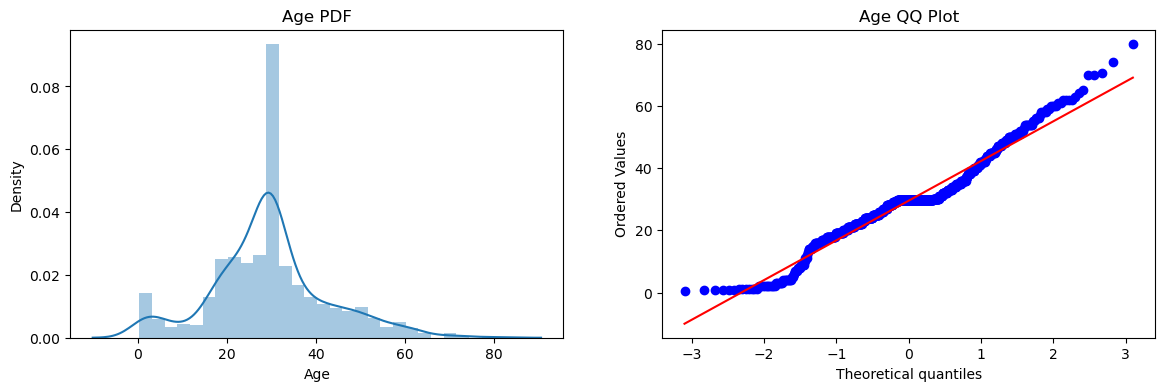

In [76]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['Age'])
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Age QQ Plot')

plt.show()

C:\Users\msi 1\AppData\Local\Temp\ipykernel_21172\474975069.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Fare'])


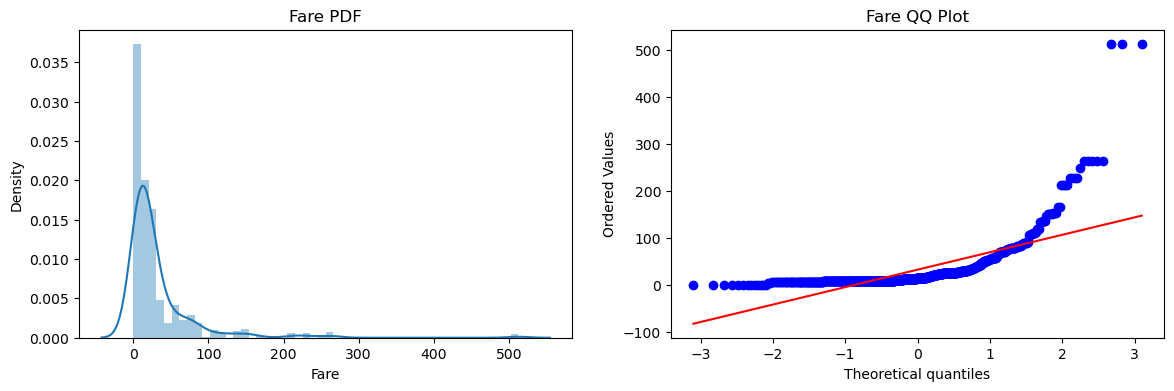

In [52]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['Fare'])
plt.title('Fare PDF')

plt.subplot(122)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Fare QQ Plot')

plt.show()

In [77]:
clf.fit(X_train,y_train)
clf2.fit(X_train,y_train)

y_pred = clf.predict(X_test)
y_pred1 = clf2.predict(X_test)

print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred1))

Accuracy LR 0.6480446927374302
Accuracy DT 0.664804469273743


In [53]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [78]:
trf = FunctionTransformer(func=np.log1p)

In [79]:
X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.transform(X_test)

In [80]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed,y_train)
clf2.fit(X_train_transformed,y_train)

y_pred = clf.predict(X_test_transformed)
y_pred1 = clf2.predict(X_test_transformed)

print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred1))

Accuracy LR 0.6815642458100558
Accuracy DT 0.6871508379888268


In [81]:
X_transformed = trf.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_transformed,y,scoring='accuracy',cv=10)))

LR 0.678027465667915
DT 0.6521223470661675


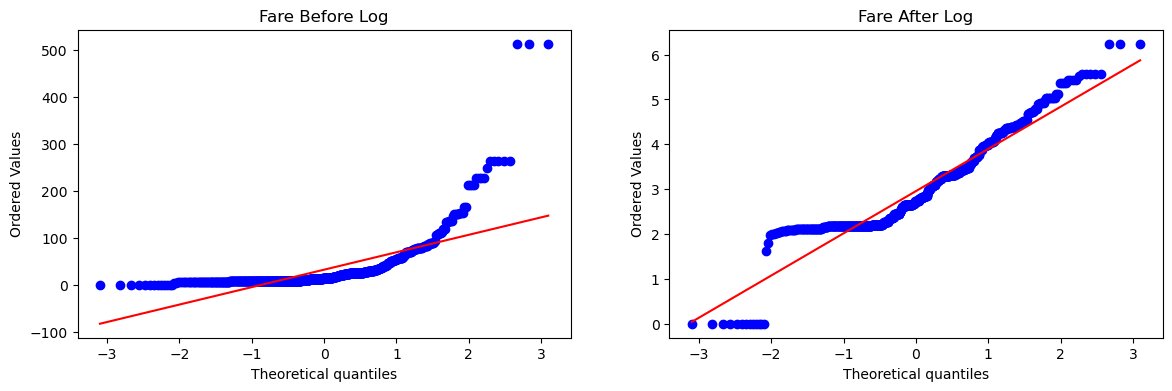

In [82]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Fare Before Log')

plt.subplot(122)
stats.probplot(X_train_transformed['Fare'], dist="norm", plot=plt)
plt.title('Fare After Log')

plt.show()

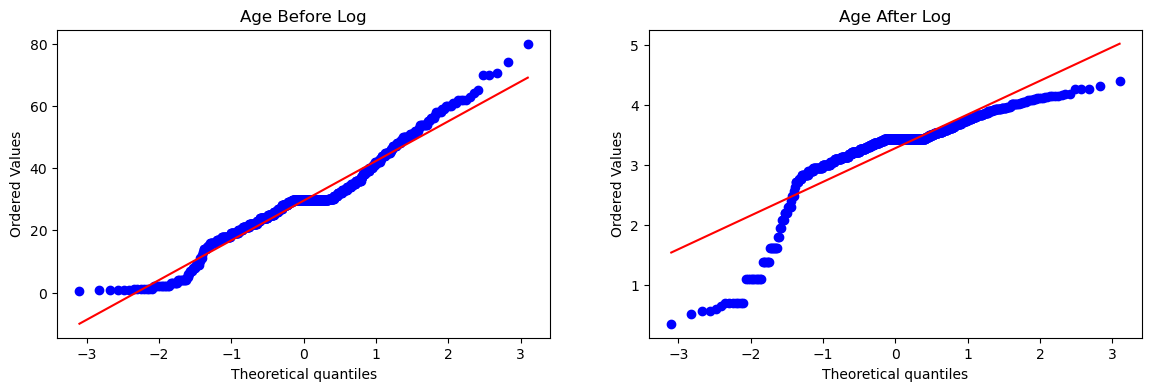

In [83]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Age Before Log')

plt.subplot(122)
stats.probplot(X_train_transformed['Age'], dist="norm", plot=plt)
plt.title('Age After Log')

plt.show()

Age was normally distributed after applying Log Transfromation it's distribution hot affected

In [84]:
trf2 = ColumnTransformer([('log',FunctionTransformer(np.log1p),['Fare'])],remainder='passthrough')

X_train_transformed2 = trf2.fit_transform(X_train)
X_test_transformed2 = trf2.transform(X_test)

In [85]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed2,y_train)
clf2.fit(X_train_transformed2,y_train)

y_pred = clf.predict(X_test_transformed2)
y_pred2 = clf2.predict(X_test_transformed2)

print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred2))

Accuracy LR 0.6703910614525139
Accuracy DT 0.6703910614525139


In [87]:
X_transformed2 = trf2.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed2,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_transformed2,y,scoring='accuracy',cv=10)))

LR 0.6712609238451936
DT 0.6565792759051186


## Sin Transformation

In [88]:
def apply_transform(transform):
    X = df.iloc[:,1:3]
    y = df.iloc[:,0]

    trf = ColumnTransformer([('log',FunctionTransformer(transform),['Fare'])],remainder='passthrough')

    X_trans = trf.fit_transform(X)

    clf = LogisticRegression()

    print("Accuracy",np.mean(cross_val_score(clf,X_trans,y,scoring='accuracy',cv=10)))

    plt.figure(figsize=(14,4))

    plt.subplot(121)
    stats.probplot(X['Fare'], dist="norm", plot=plt)
    plt.title('Fare Before Transform')

    plt.subplot(122)
    stats.probplot(X_trans[:,0], dist="norm", plot=plt)
    plt.title('Fare After Transform')

    plt.show()

Accuracy 0.6195131086142323


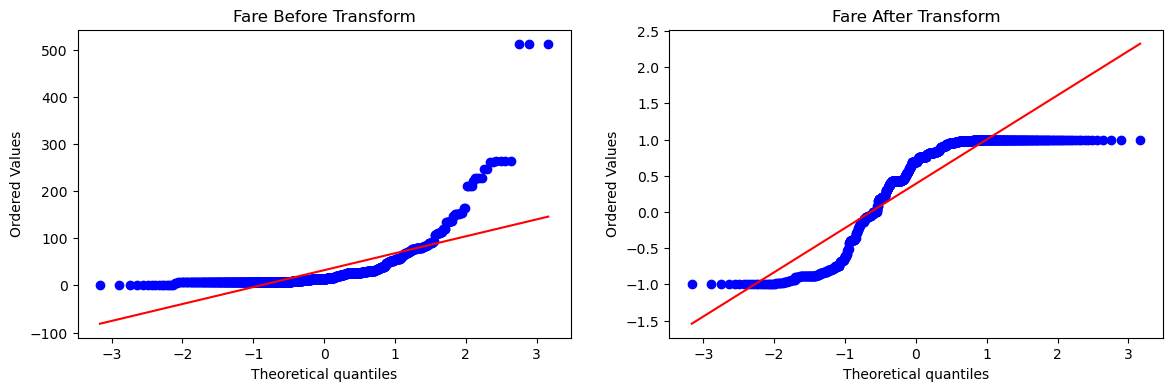

In [89]:
apply_transform(np.sin)

## Squared TransFormation

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Seed for reproducibility
np.random.seed(42)

# Generate 200 random X values between 0 and 10
X = np.random.uniform(0, 10, 200)

# Calculate Y using a quadratic relationship and add some noise
Y = -X**2 + 10*X + np.random.normal(0, 5, 200)

# Convert X and Y into a DataFrame for easier manipulation
df = pd.DataFrame({'X': X, 'Y': Y})

df.head()

,X,Y
0,3.745401,20.025858
1,9.507143,5.846930
2,7.319939,21.083243
3,5.986585,20.454893
4,1.560186,22.496555


In [2]:
df['X_squared'] = df['X']**2

df.head()

,X,Y,X_squared
0,3.745401,20.025858,14.028030
1,9.507143,5.846930,90.385769
2,7.319939,21.083243,53.581513
3,5.986585,20.454893,35.839198
4,1.560186,22.496555,2.434182


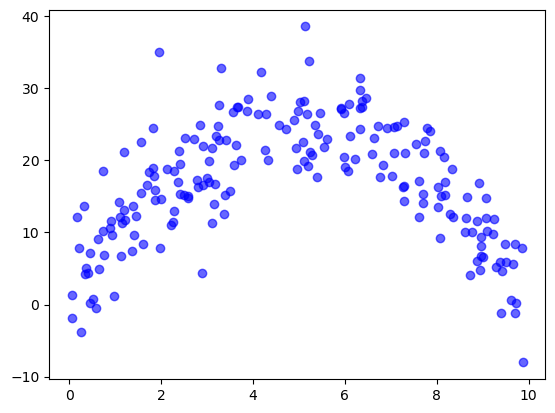

In [3]:
df_sorted = df.sort_values(by='X')

plt.scatter(df_sorted['X'], df_sorted['Y'], color='blue', label='Actual Data', alpha=0.6)

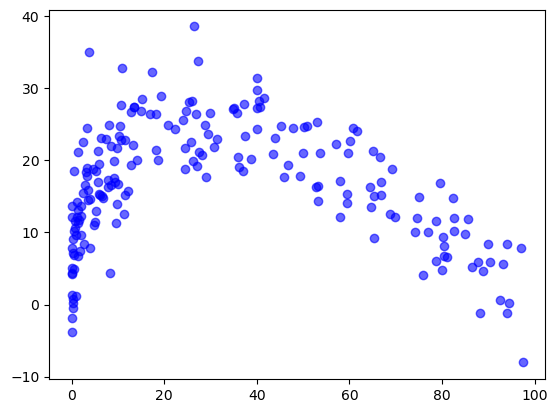

In [4]:
plt.scatter(df_sorted['X_squared'], df_sorted['Y'], color='blue', label='Actual Data', alpha=0.6)

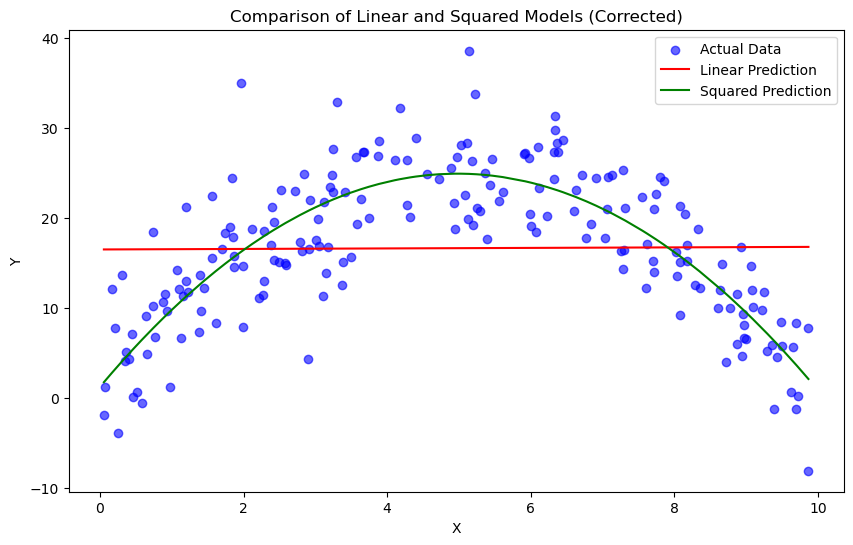

In [5]:
# Linear model using X
linear_model = LinearRegression()
linear_model.fit(df[['X']], df['Y'])
df['Linear_Prediction'] = linear_model.predict(df[['X']])

# Linear model using X^2
df['X_squared'] = df['X']**2
squared_model = LinearRegression()
squared_model.fit(df[['X', 'X_squared']], df['Y'])
df['Squared_Prediction'] = squared_model.predict(df[['X', 'X_squared']])

# Sort the dataframe by X values for better plotting
df_sorted = df.sort_values(by='X')

# Plot the data and the models with sorted values
plt.figure(figsize=(10, 6))
plt.scatter(df_sorted['X'], df_sorted['Y'], color='blue', label='Actual Data', alpha=0.6)
plt.plot(df_sorted['X'], df_sorted['Linear_Prediction'], color='red', label='Linear Prediction')
plt.plot(df_sorted['X'], df_sorted['Squared_Prediction'], color='green', label='Squared Prediction')
plt.title('Comparison of Linear and Squared Models (Corrected)')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

In [6]:
import numpy as np
import pandas as pd

In [7]:
df = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv')

In [8]:
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [9]:
df.skew()['crim']

np.float64(5.223148798243851)

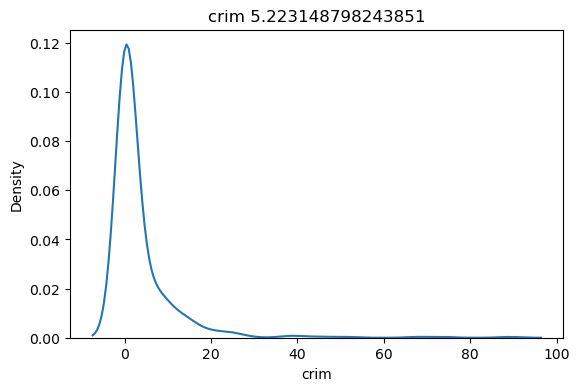

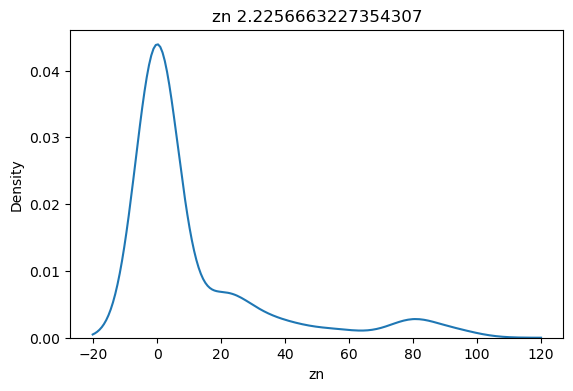

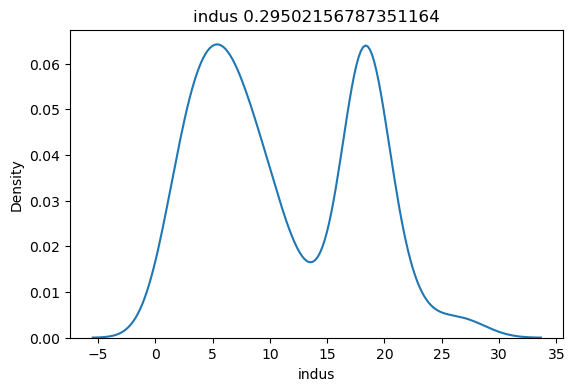

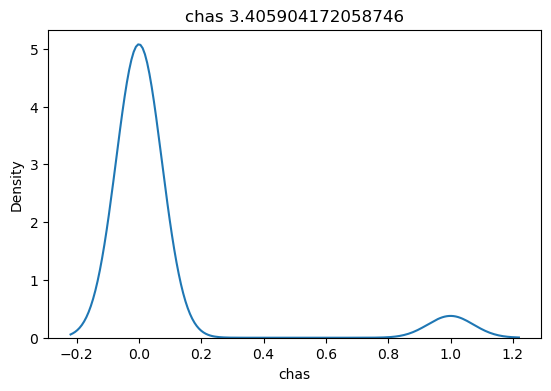

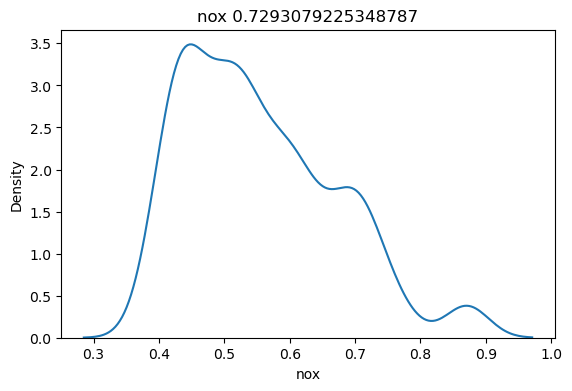

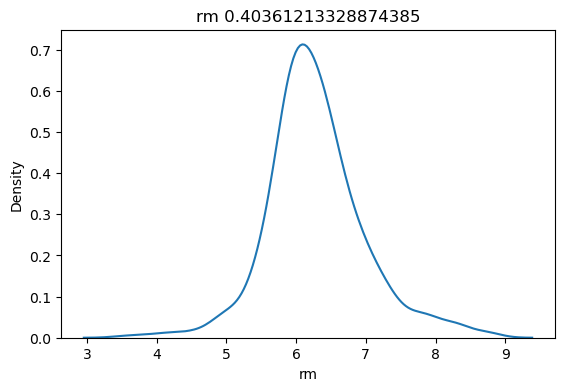

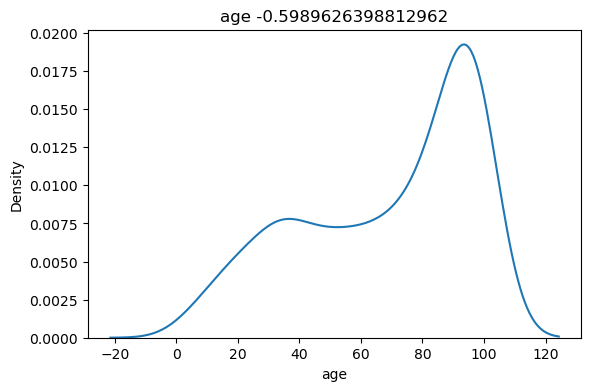

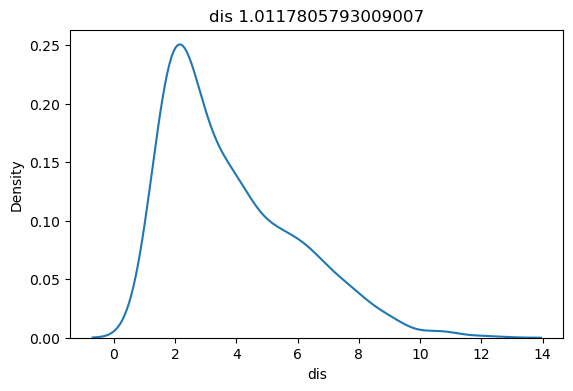

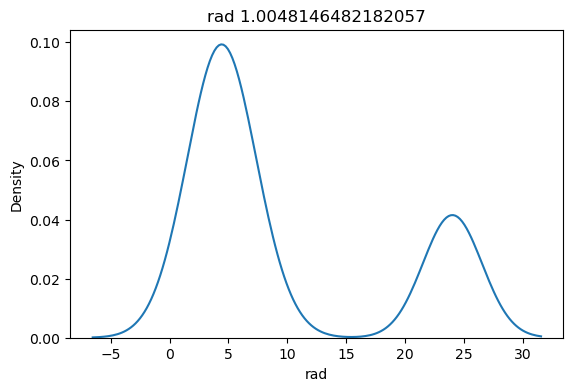

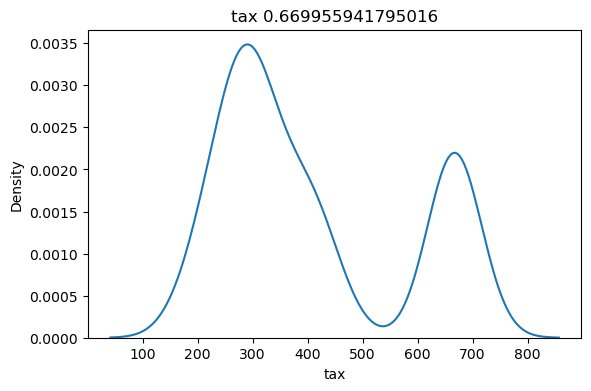

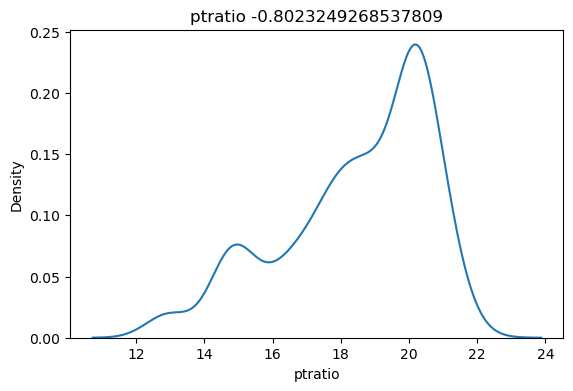

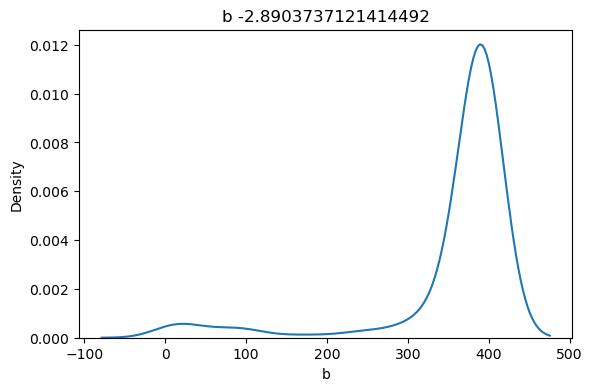

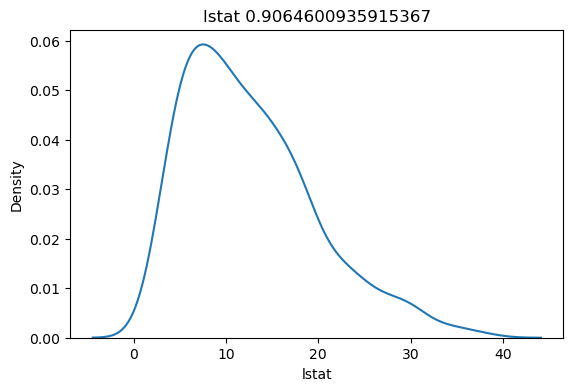

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the distplots without any transformation

for col in df.columns[0:-1]:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.kdeplot(df[col])
    txt = col + " " + str(df.skew()[col])
    plt.title(txt)
    plt.show()

## Applying All Transformations

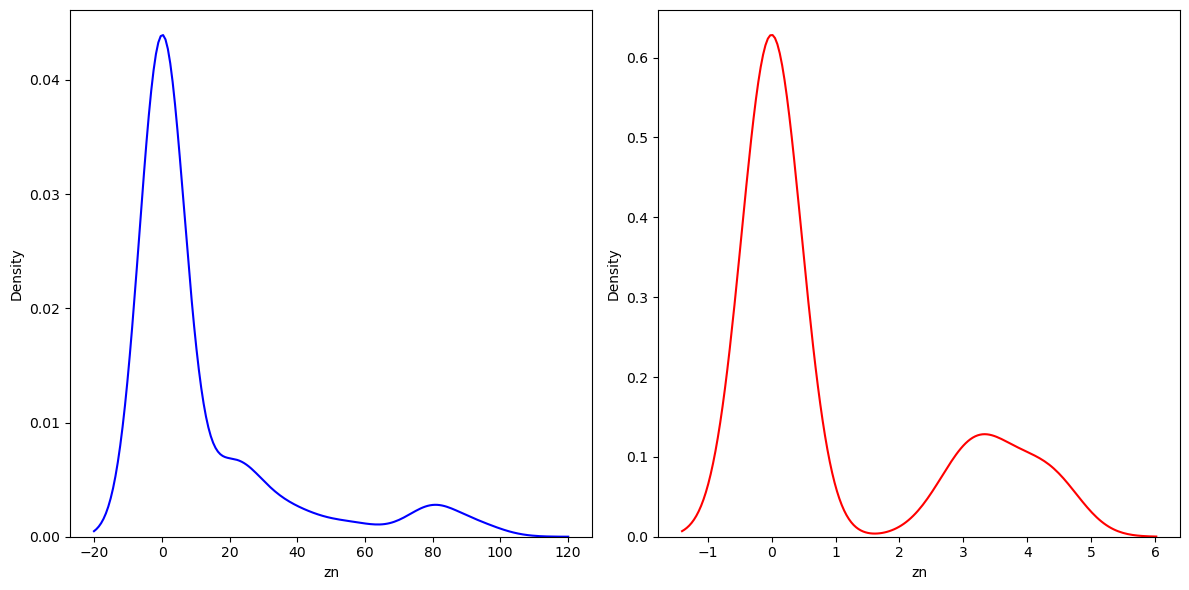

skew before log transform 2.219063057148425
skew after log transform 1.1899105701640726


In [11]:
# log on zn feature

# Setting up the matplotlib figure with two subplots
fig, axs = plt.subplots(ncols=2, figsize=(12, 6))

# Plotting the normal distribution
sns.kdeplot(df['zn'], color='blue', ax=axs[0])

# Plotting the exponential distribution
sns.kdeplot(np.log1p(df['zn']), color='red', ax=axs[1])

plt.tight_layout()
plt.show()

from scipy.stats import skew

print('skew before log transform', skew(df['zn']))
print('skew after log transform', skew(np.log1p(df['zn'])))

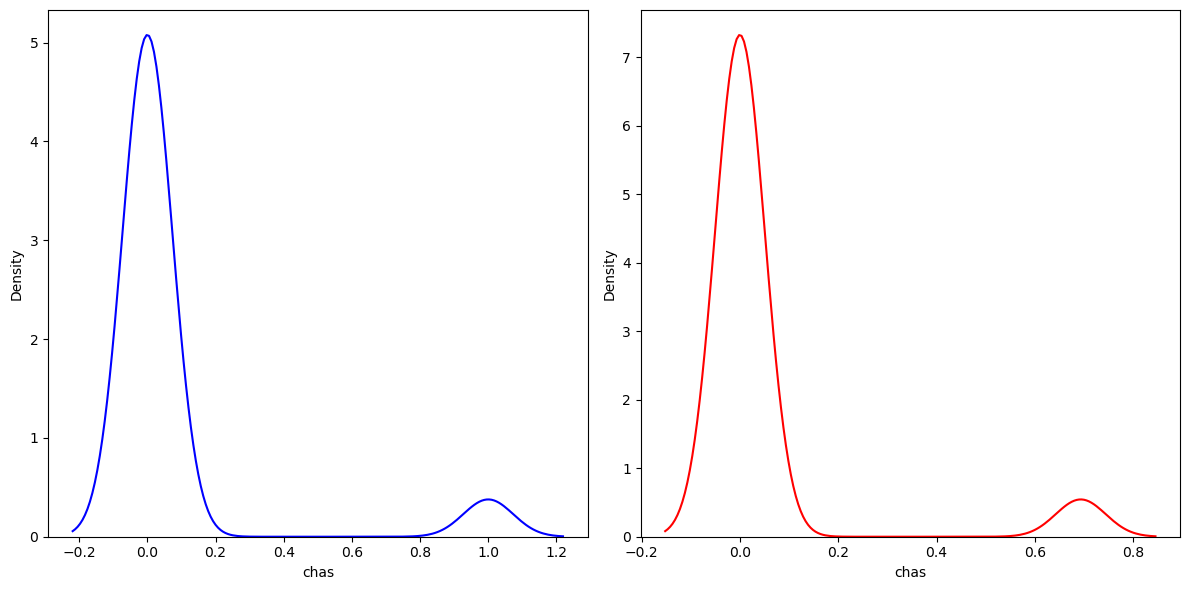

skew before reciprocal transform 3.395799292642519
skew after reciprocal transform 3.3957992926425202


In [12]:
# log on chas

# Setting up the matplotlib figure with two subplots
fig, axs = plt.subplots(ncols=2, figsize=(12, 6))

# Plotting the normal distribution
sns.kdeplot(df['chas'], color='blue', ax=axs[0])

# Plotting the exponential distribution
sns.kdeplot(np.log1p(df['chas']), color='red', ax=axs[1])

plt.tight_layout()
plt.show()

from scipy.stats import skew

print('skew before reciprocal transform', skew(df['chas']))
print('skew after reciprocal transform', skew(np.log1p(df['chas'])))

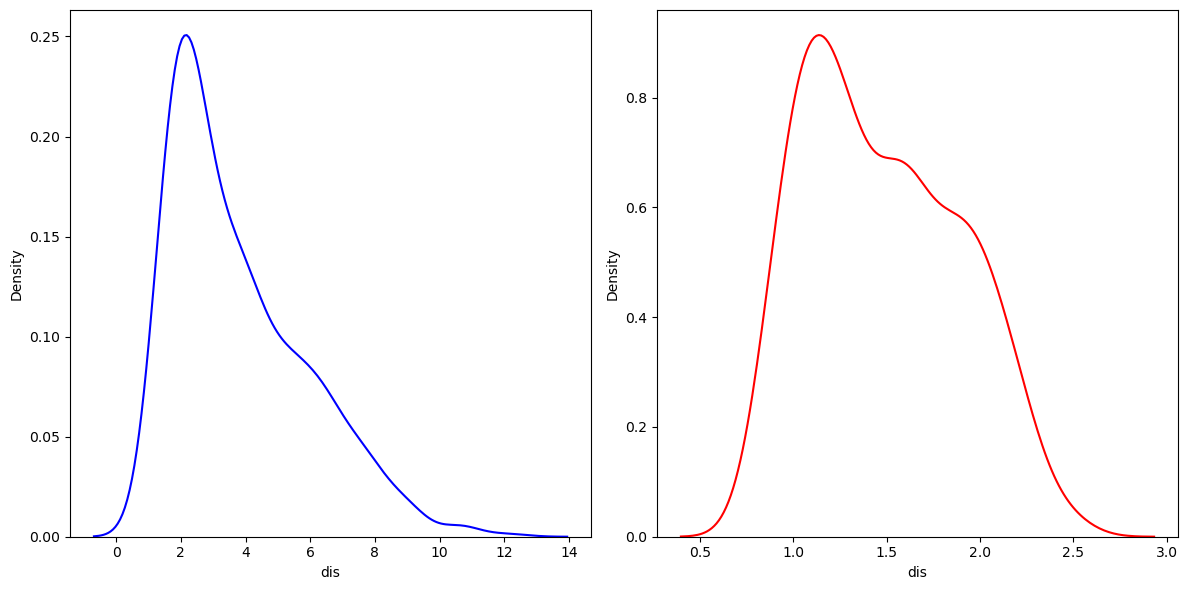

skew before log transform 1.0087787565152246
skew after log transform 0.3305777426343001


In [13]:
# log on dis

# Setting up the matplotlib figure with two subplots
fig, axs = plt.subplots(ncols=2, figsize=(12, 6))

# Plotting the normal distribution
sns.kdeplot(df['dis'], color='blue', ax=axs[0])

# Plotting the exponential distribution
sns.kdeplot(np.log1p(df['dis']), color='red', ax=axs[1])

plt.tight_layout()
plt.show()

from scipy.stats import skew

print('skew before log transform', skew(df['dis']))
print('skew after log transform', skew(np.log1p(df['dis'])))

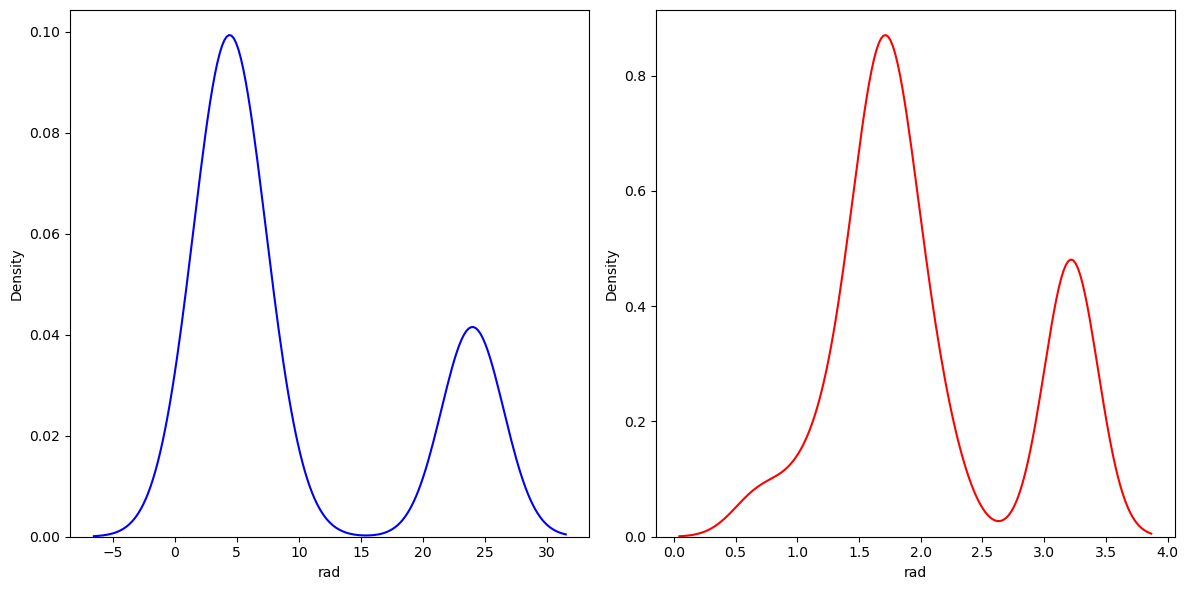

skew before log transform 1.0018334924536951
skew after log transform 0.5311793311965491


In [14]:
# log on rad

# Setting up the matplotlib figure with two subplots
fig, axs = plt.subplots(ncols=2, figsize=(12, 6))

# Plotting the normal distribution
sns.kdeplot(df['rad'], color='blue', ax=axs[0])

# Plotting the exponential distribution
sns.kdeplot(np.log1p(df['rad']), color='red', ax=axs[1])

plt.tight_layout()
plt.show()

from scipy.stats import skew

print('skew before log transform', skew(df['rad']))
print('skew after log transform', skew(np.log1p(df['rad'])))

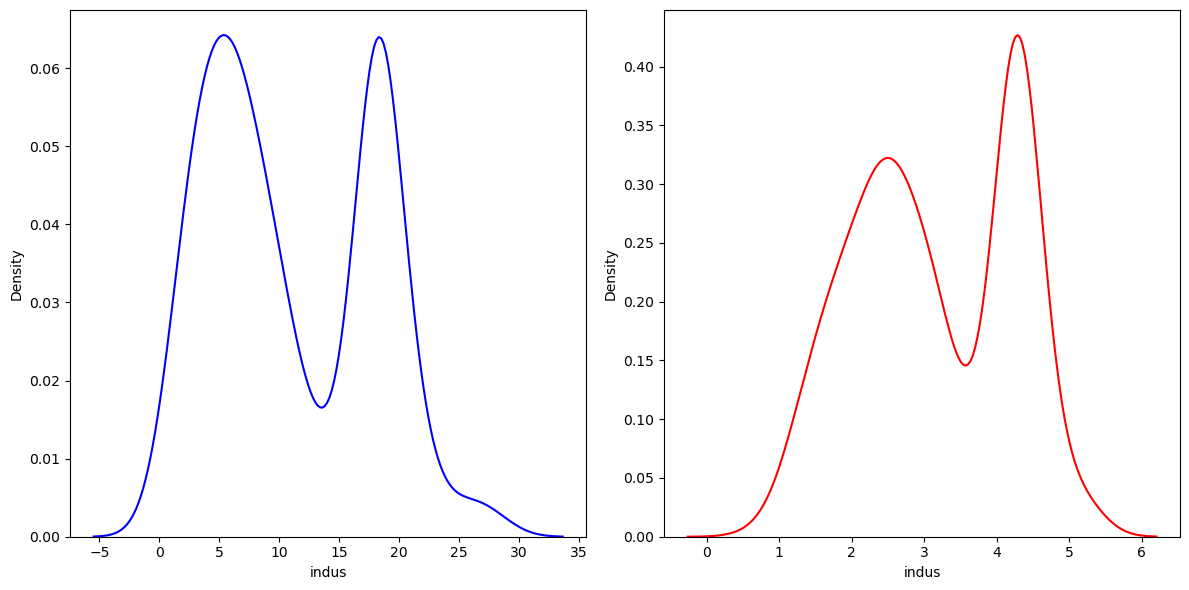

skew before sqrt transform 0.29414627684418543
skew after sqrt transform -0.07239396333108224


In [15]:
# sqrt on indus

# Setting up the matplotlib figure with two subplots
fig, axs = plt.subplots(ncols=2, figsize=(12, 6))

# Plotting the normal distribution
sns.kdeplot(df['indus'], color='blue', ax=axs[0])

# Plotting the exponential distribution
sns.kdeplot(np.sqrt(df['indus']), color='red', ax=axs[1])

plt.tight_layout()
plt.show()

from scipy.stats import skew

print('skew before sqrt transform', skew(df['indus']))
print('skew after sqrt transform', skew(np.sqrt(df['indus'])))

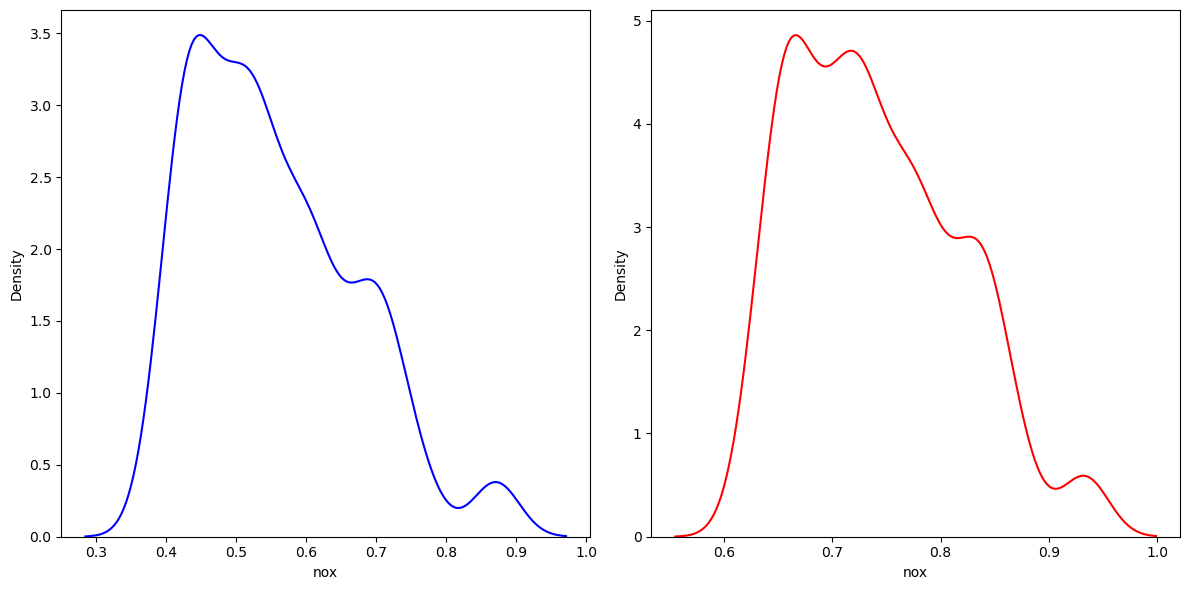

skew before sqrt transform 0.7271441597740319
skew after sqrt transform 0.5351964490014817


In [16]:
# sqrt on nox

# Setting up the matplotlib figure with two subplots
fig, axs = plt.subplots(ncols=2, figsize=(12, 6))

# Plotting the normal distribution
sns.kdeplot(df['nox'], color='blue', ax=axs[0])

# Plotting the exponential distribution
sns.kdeplot(np.sqrt(df['nox']), color='red', ax=axs[1])

plt.tight_layout()
plt.show()

from scipy.stats import skew

print('skew before sqrt transform', skew(df['nox']))
print('skew after sqrt transform', skew(np.sqrt(df['nox'])))

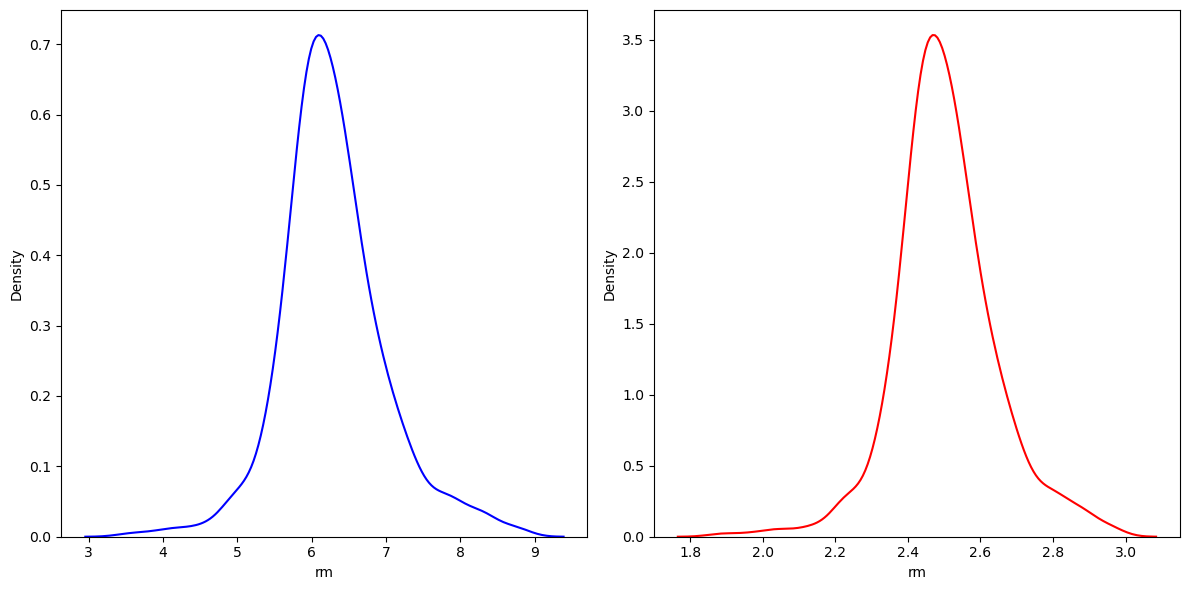

skew before sqrt transform 0.40241466802496245
skew after sqrt transform 0.07249861410468098


In [17]:
# sqrt on rm

# Setting up the matplotlib figure with two subplots
fig, axs = plt.subplots(ncols=2, figsize=(12, 6))

# Plotting the normal distribution
sns.kdeplot(df['rm'], color='blue', ax=axs[0])

# Plotting the exponential distribution
sns.kdeplot(np.sqrt(df['rm']), color='red', ax=axs[1])

plt.tight_layout()
plt.show()

from scipy.stats import skew

print('skew before sqrt transform', skew(df['rm']))
print('skew after sqrt transform', skew(np.sqrt(df['rm'])))

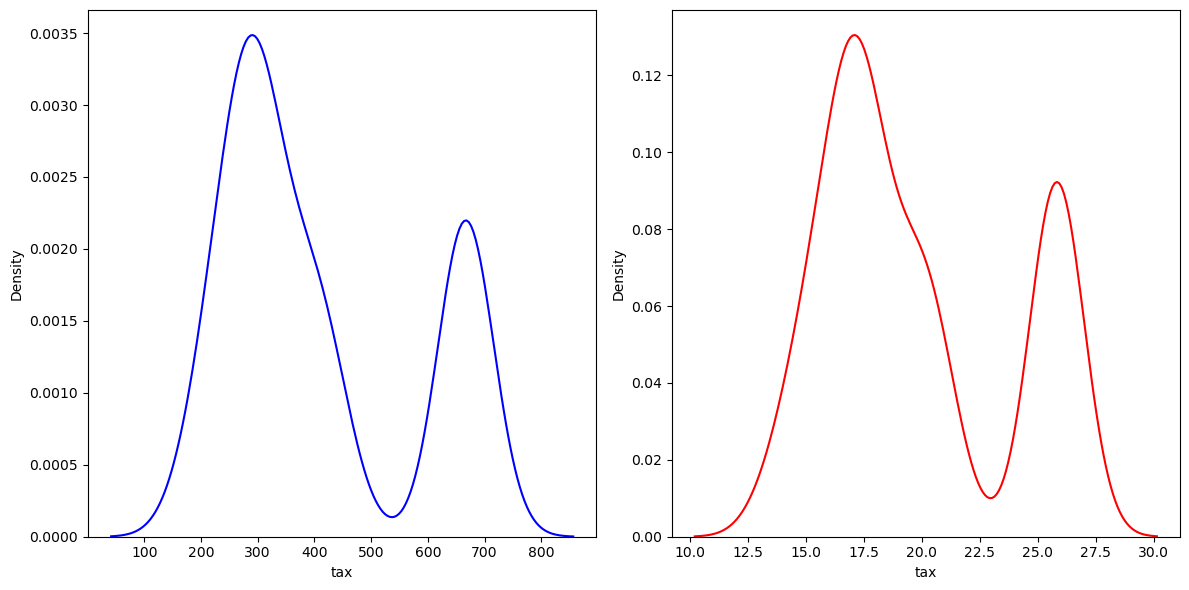

skew before sqrt transform 0.6679682687237768
skew after sqrt transform 0.5202453627239406


In [18]:
# sqrt on tax

# Setting up the matplotlib figure with two subplots
fig, axs = plt.subplots(ncols=2, figsize=(12, 6))

# Plotting the normal distribution
sns.kdeplot(df['tax'], color='blue', ax=axs[0])

# Plotting the exponential distribution
sns.kdeplot(np.sqrt(df['tax']), color='red', ax=axs[1])

plt.tight_layout()
plt.show()

from scipy.stats import skew

print('skew before sqrt transform', skew(df['tax']))
print('skew after sqrt transform', skew(np.sqrt(df['tax'])))

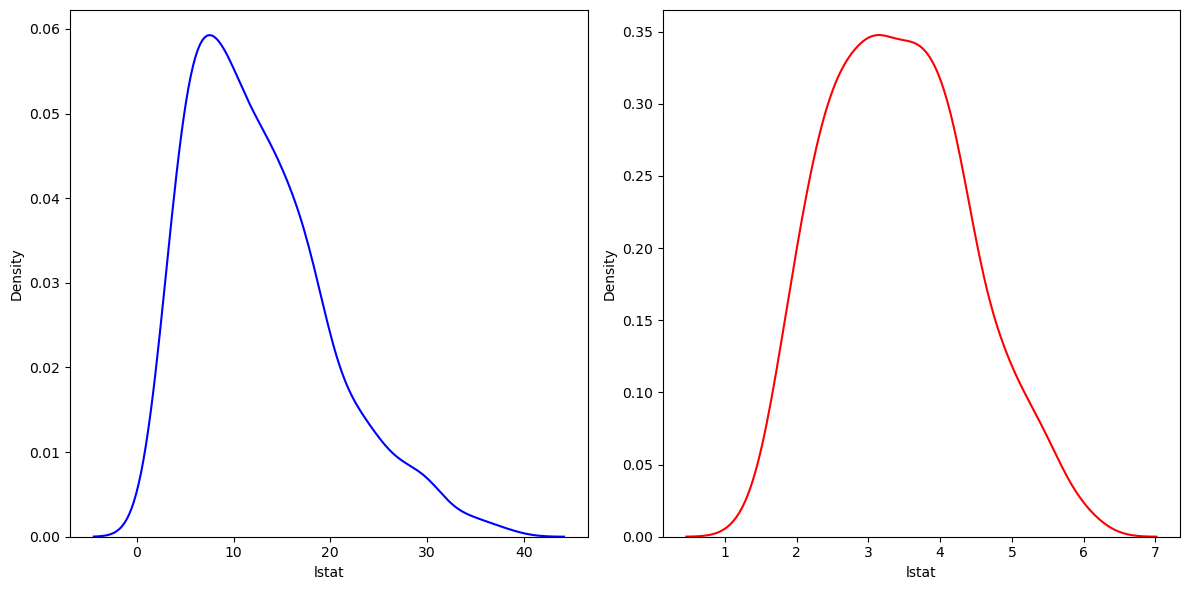

skew before sqrt transform 0.9037707431346133
skew after sqrt transform 0.30647851994358943


In [19]:
# sqrt on lstat

# Setting up the matplotlib figure with two subplots
fig, axs = plt.subplots(ncols=2, figsize=(12, 6))

# Plotting the normal distribution
sns.kdeplot(df['lstat'], color='blue', ax=axs[0])

# Plotting the exponential distribution
sns.kdeplot(np.sqrt(df['lstat']), color='red', ax=axs[1])

plt.tight_layout()
plt.show()

from scipy.stats import skew

print('skew before sqrt transform', skew(df['lstat']))
print('skew after sqrt transform', skew(np.sqrt(df['lstat'])))

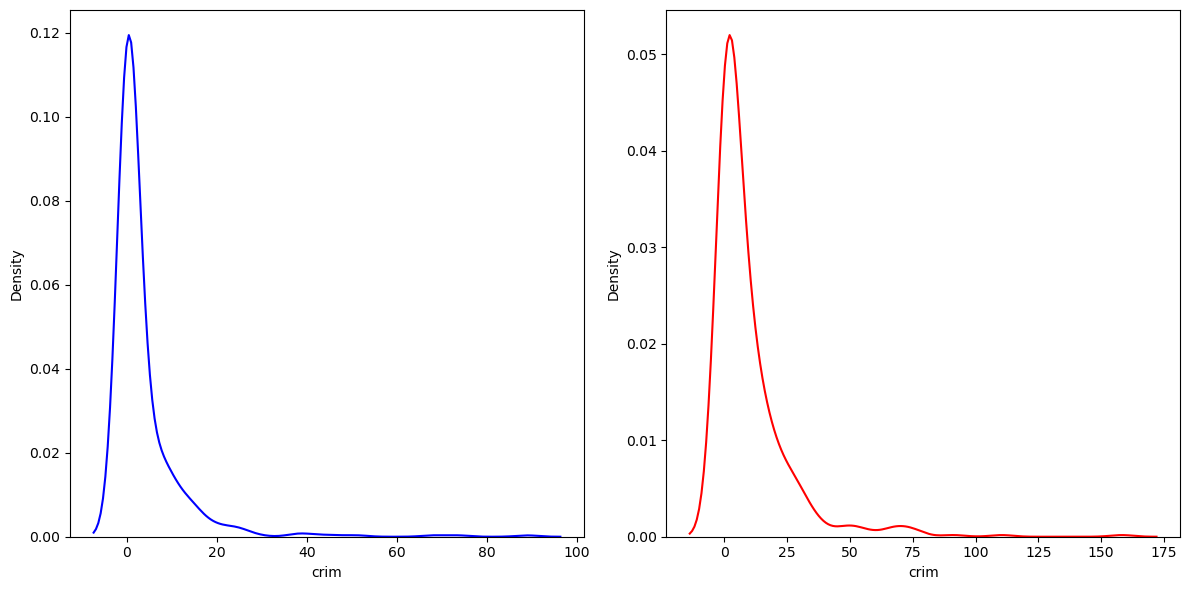

skew before reciprocal transform 5.207652387859715
skew after reciprocal transform 3.733474573321791


In [20]:
# reciprocal on crim

# Setting up the matplotlib figure with two subplots
fig, axs = plt.subplots(ncols=2, figsize=(12, 6))

# Plotting the normal distribution
sns.kdeplot(df['crim'], color='blue', ax=axs[0])

# Plotting the exponential distribution
sns.kdeplot(np.reciprocal(df['crim']), color='red', ax=axs[1])

plt.tight_layout()
plt.show()

from scipy.stats import skew

print('skew before reciprocal transform', skew(df['crim']))
print('skew after reciprocal transform', skew(np.reciprocal(df['crim'])))

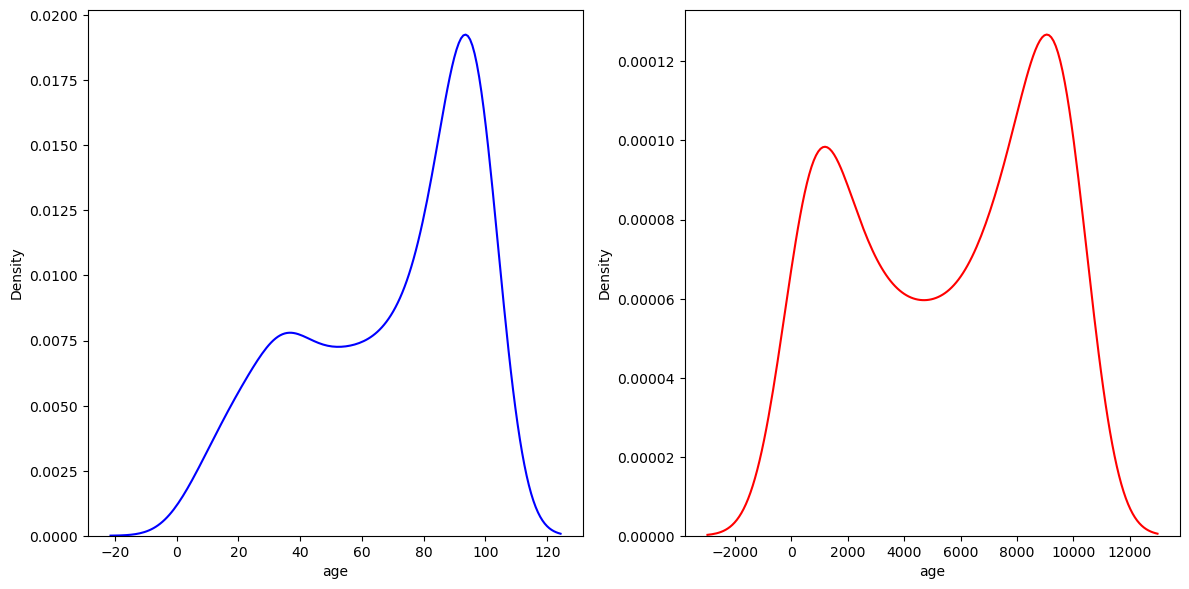

skew before reciprocal transform -0.5971855948016143
skew after reciprocal transform -0.18263633415807376


In [21]:
# square on age

# Setting up the matplotlib figure with two subplots
fig, axs = plt.subplots(ncols=2, figsize=(12, 6))

# Plotting the normal distribution
sns.kdeplot(df['age'], color='blue', ax=axs[0])

# Plotting the exponential distribution
sns.kdeplot(np.square(df['age']), color='red', ax=axs[1])

plt.tight_layout()
plt.show()

from scipy.stats import skew

print('skew before reciprocal transform', skew(df['age']))
print('skew after reciprocal transform', skew(np.square(df['age'])))

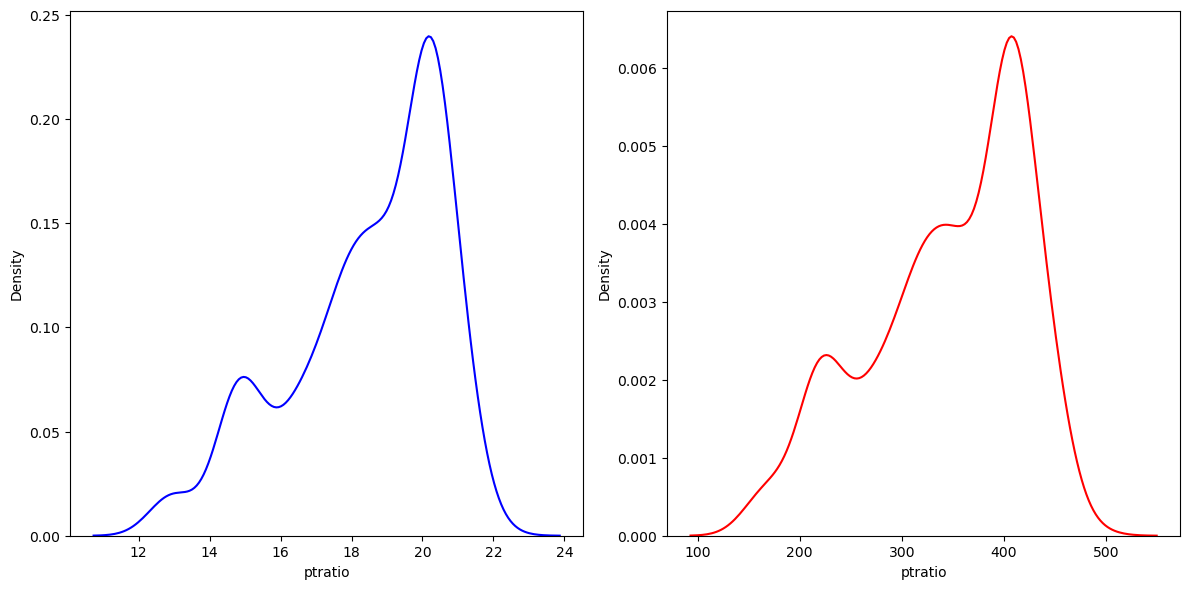

skew before reciprocal transform -0.7999445320367449
skew after reciprocal transform -0.6085086626298968


In [22]:
# square on ptratio

# Setting up the matplotlib figure with two subplots
fig, axs = plt.subplots(ncols=2, figsize=(12, 6))

# Plotting the normal distribution
sns.kdeplot(df['ptratio'], color='blue', ax=axs[0])

# Plotting the exponential distribution
sns.kdeplot(np.square(df['ptratio']), color='red', ax=axs[1])

plt.tight_layout()
plt.show()

from scipy.stats import skew

print('skew before reciprocal transform', skew(df['ptratio']))
print('skew after reciprocal transform', skew(np.square(df['ptratio'])))

In [23]:
-df['b']

0     -396.90
1     -396.90
2     -392.83
3     -394.63
4     -396.90
        ...  
501   -391.99
502   -396.90
503   -396.90
504   -393.45
505   -396.90
Name: b, Length: 506, dtype: float64

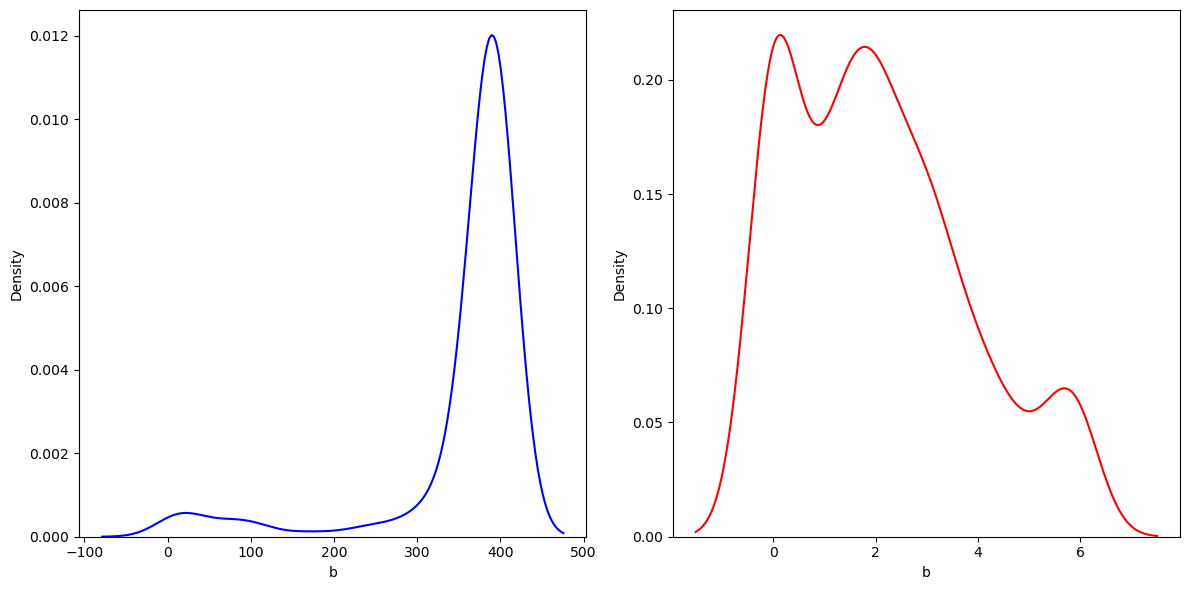

skew before reflect log transform -2.8817983452627716
skew after reflect log transform 0.5995750622214899


In [24]:
# reflect log on b

# Setting up the matplotlib figure with two subplots
fig, axs = plt.subplots(ncols=2, figsize=(12, 6))

# Plotting the normal distribution
sns.kdeplot(df['b'], color='blue', ax=axs[0])

# Plotting the exponential distribution
sns.kdeplot(np.log1p(-df['b'] + 396.900000001), color='red', ax=axs[1])

plt.tight_layout()
plt.show()

from scipy.stats import skew

print('skew before reflect log transform', skew(df['b']))
print('skew after reflect log transform', skew(np.log1p(-df['b'] + 396.900000001)))

In [ ]:
# log -> zn, chas, dis, rad
# sqrt -> indus, nox, rm, tax, lstat
# reciprocal -> crim
# square -> age, ptratio
# reflect shift log -> b

In [25]:
# baseline model

from sklearn.model_selection import train_test_split

# Define your features and target variable
X = df.drop('medv', axis=1)  # Features
y = df['medv']  # Target variable

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression()

reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[-0.11, 0.03, 0.04,...,-0.92, 0.01,-0.51]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](13,)","['crim','zn','indus',...,'ptratio','b','lstat']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,30.25
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,13


In [27]:
from sklearn.metrics import r2_score, mean_squared_error

y_pred = reg.predict(X_test)

print('r2 score', r2_score(y_test, y_pred))
print('mse', mean_squared_error(y_test, y_pred))

r2 score 0.6687594935356291
mse 24.29111947497373


In [28]:
def reflect_shift_log_transform(x):

    return np.log1p(-x + 396.900000001)

In [29]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('log', FunctionTransformer(np.log1p), ['zn', 'chas', 'dis', 'rad']),
        ('sqrt', FunctionTransformer(np.sqrt), ['indus', 'nox', 'rm', 'tax', 'lstat']),
        ('reciprocal', FunctionTransformer(np.reciprocal), ['crim']),
        ('square', FunctionTransformer(np.square), ['age', 'ptratio']),
        ('reflect_shift_log', FunctionTransformer(reflect_shift_log_transform), ['b']),
    ],
    remainder='passthrough'  # Keeps columns not listed unchanged
)

In [30]:
X_train_trf = preprocessor.fit_transform(X_train)

In [31]:
X_test_trf = preprocessor.transform(X_test)

In [32]:
reg = LinearRegression()

reg.fit(X_train_trf, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[ 0.22, 4.29,-8.93,..., 0. ,-0.02,-0.12]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,47.49
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,13
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](13,)","[68626.76, 1519.31, 247.29,..., 3.44, 1.95, 0.67]"


In [33]:
y_pred = reg.predict(X_test_trf)

print('r2 score', r2_score(y_test, y_pred))
print('mse', mean_squared_error(y_test, y_pred))

r2 score 0.7219859878031216
mse 20.387819285977265


### Box-Cox Transform

In [34]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='box-cox')

X_train_transformed = pt.fit_transform(X_train+0.000001)
X_test_transformed = pt.transform(X_test+0.000001)

pd.DataFrame({'cols':X_train.columns,'box_cox_lambdas':pt.lambdas_})

,cols,box_cox_lambdas
0,crim,-0.114374
1,zn,-0.181510
2,indus,0.389192
3,chas,-1.008349
4,nox,-0.938023
5,rm,0.147907
6,age,1.362922
7,dis,-0.165778
8,rad,-0.134975
9,tax,-0.526450


In [35]:
reg = LinearRegression()

reg.fit(X_train_transformed, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[ 0.88, 0.24,-0.56,...,-1.41, 0.72,-5.63]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,22.8
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,13
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](13,)","[52.07,23.43,21.06,..., 8.13, 6.92, 6.36]"


In [36]:
y_pred = reg.predict(X_test_transformed)

print('r2 score', r2_score(y_test, y_pred))
print('mse', mean_squared_error(y_test, y_pred))

r2 score 0.7321931087888249
mse 19.639292488920514


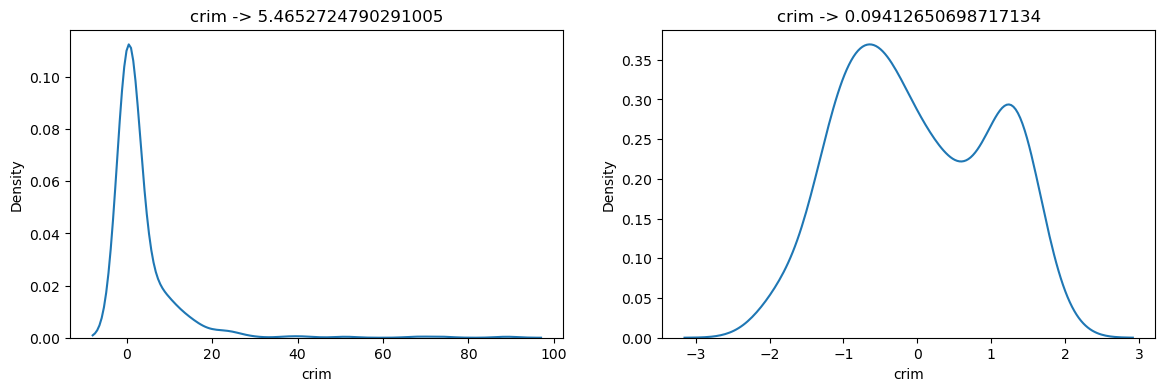

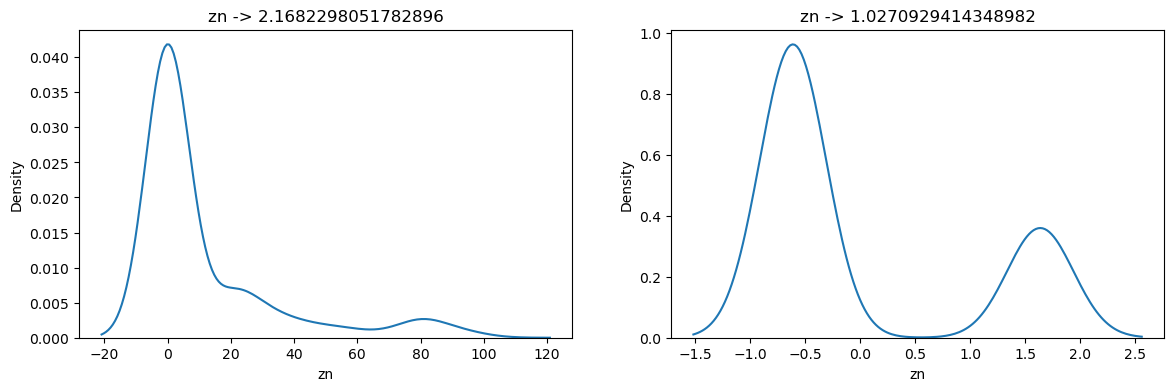

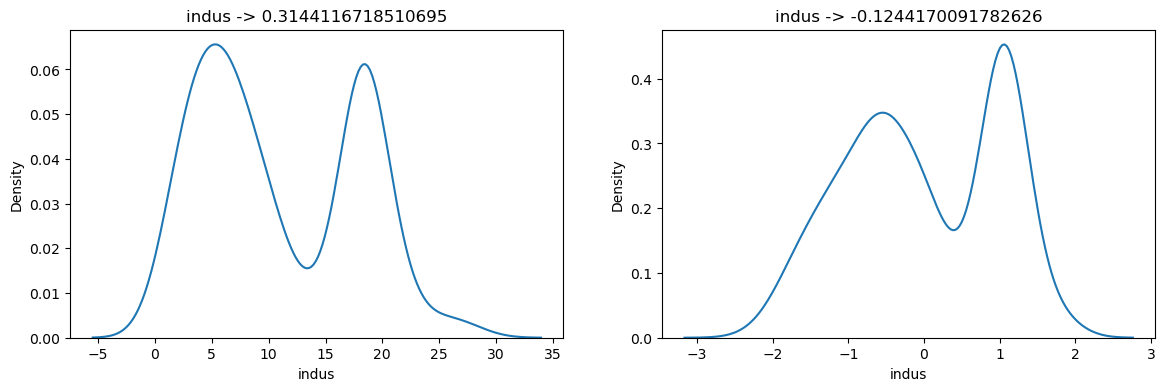

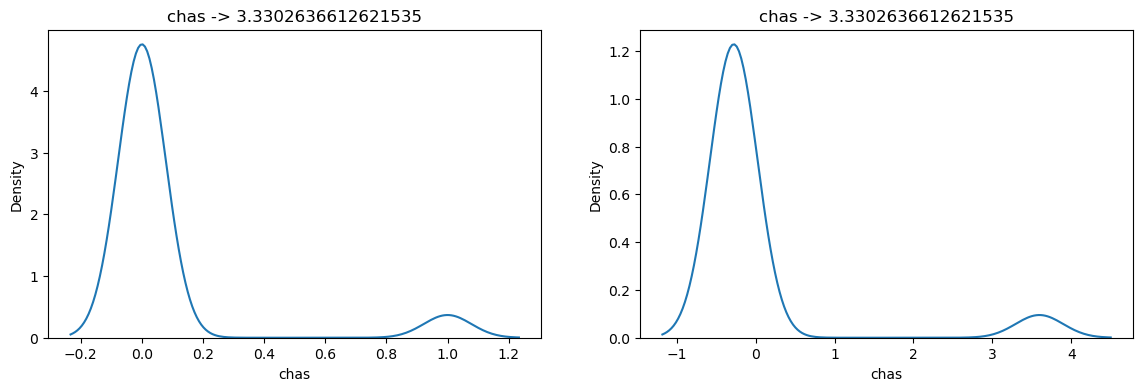

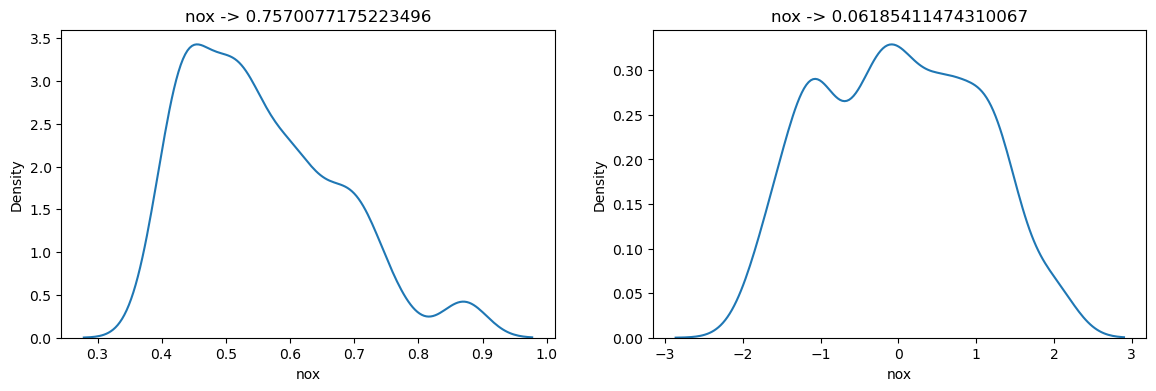

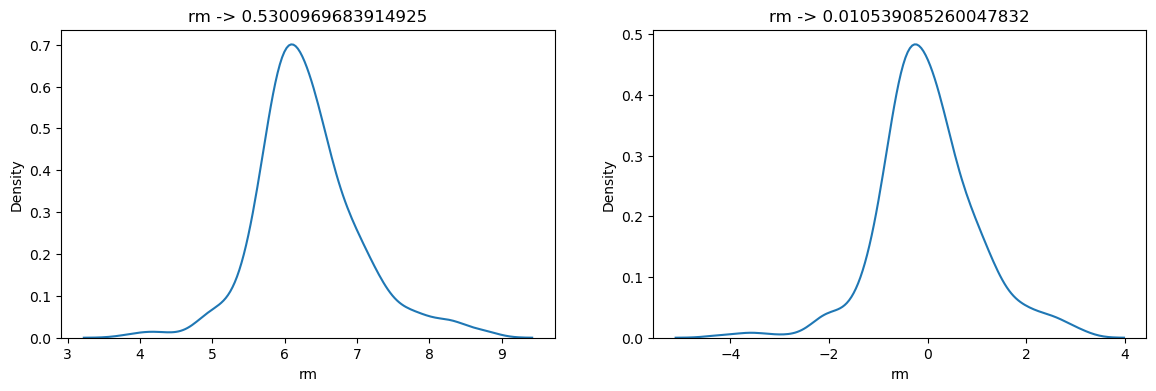

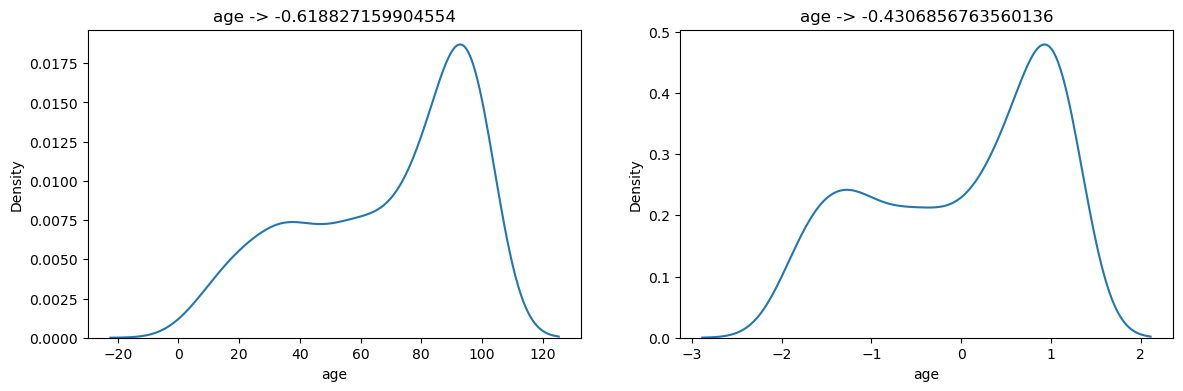

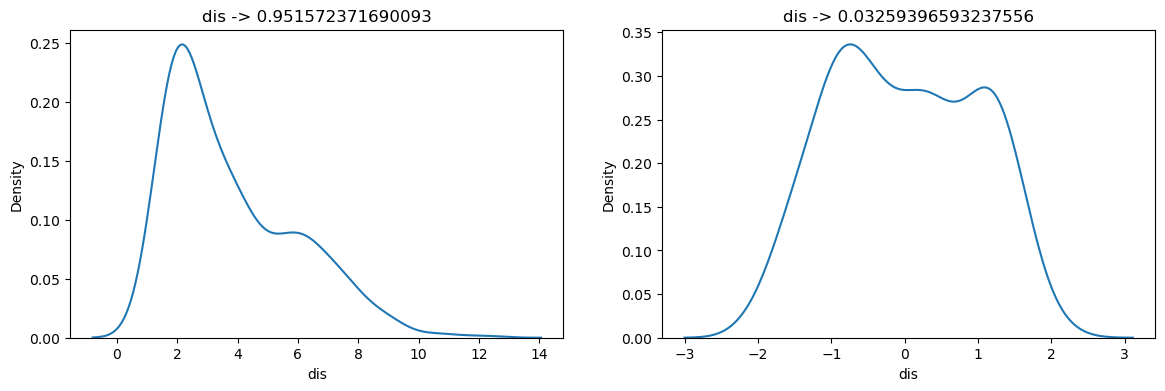

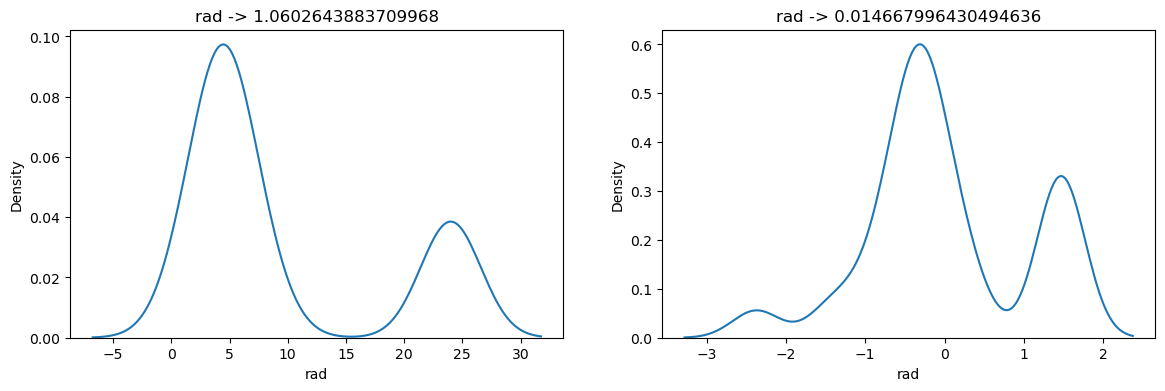

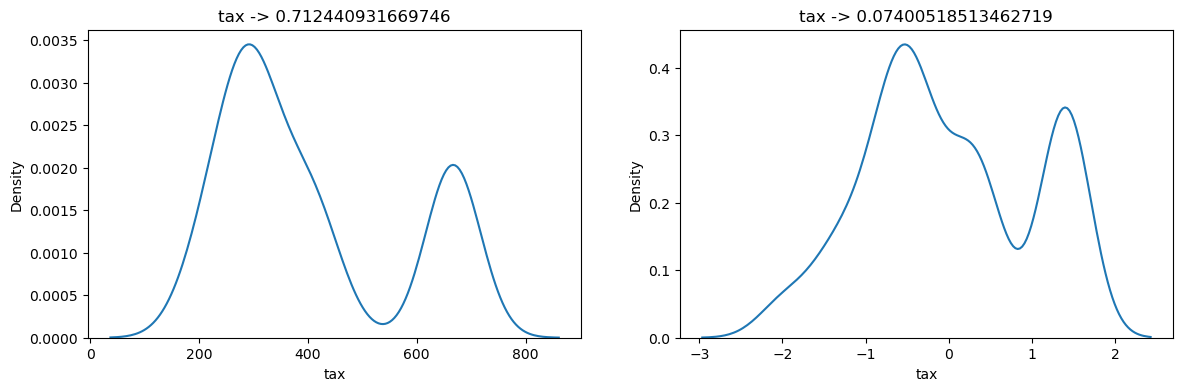

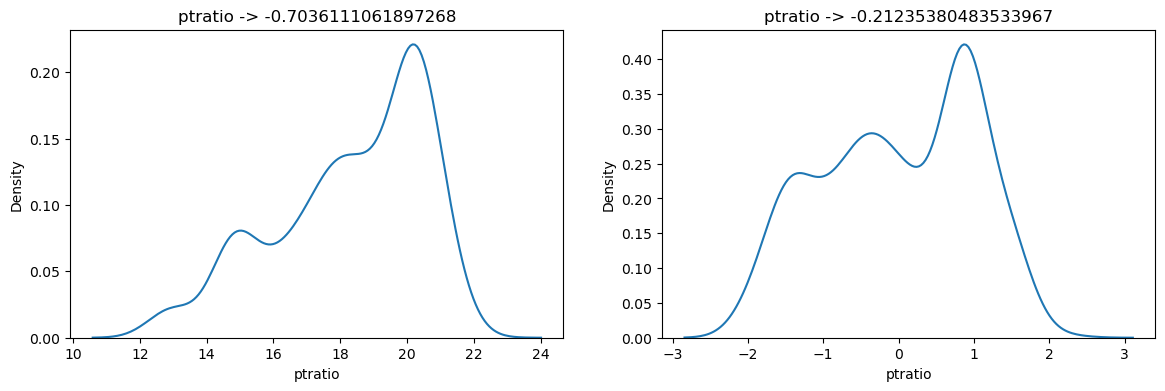

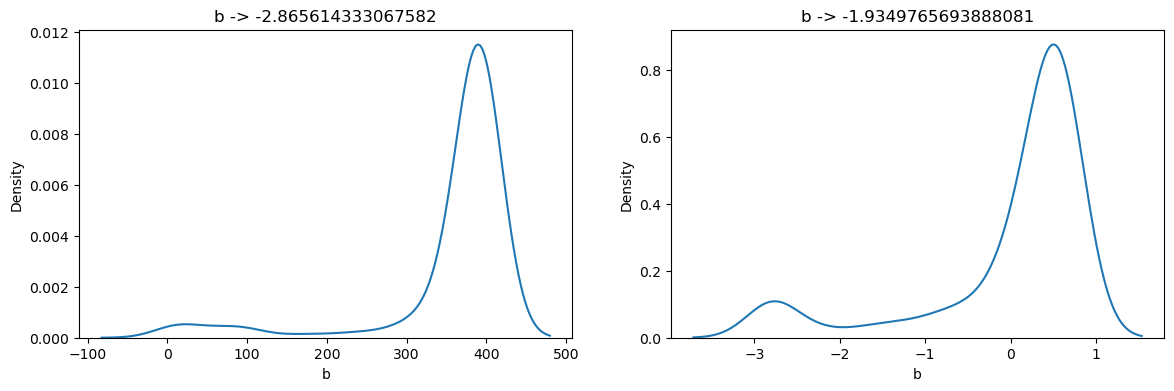

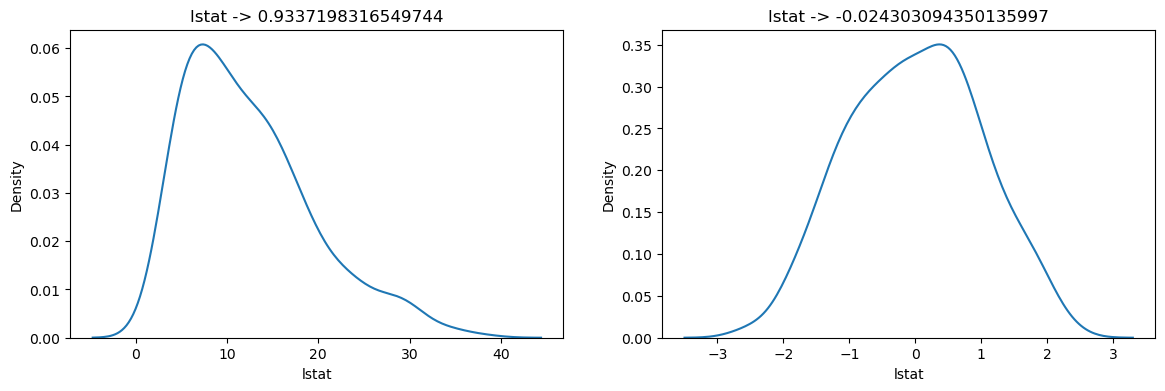

In [37]:
# Before and after comparision for Box-Cox Plot
X_train_transformed = pd.DataFrame(X_train_transformed,columns=X_train.columns)

for col in X_train_transformed.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.kdeplot(X_train[col])
    txt = col + " -> " + str(X_train[col].skew())
    plt.title(txt)

    plt.subplot(122)
    sns.kdeplot(X_train_transformed[col])
    txt1 = col + " -> " + str(X_train_transformed[col].skew())
    plt.title(txt1)

    plt.show()

### Yeo-Johnson

In [38]:
# Apply Yeo-Johnson transform

pt1 = PowerTransformer()

X_train_transformed2 = pt1.fit_transform(X_train)
X_test_transformed2 = pt1.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_transformed2,y_train)

y_pred3 = lr.predict(X_test_transformed2)

print(r2_score(y_test,y_pred3))

pd.DataFrame({'cols':X_train.columns,'Yeo_Johnson_lambdas':pt1.lambdas_})

0.731491412595775


,cols,Yeo_Johnson_lambdas
0,crim,-0.958995
1,zn,-0.867045
2,indus,0.332416
3,chas,-20.097985
4,nox,-4.033137
5,rm,-0.014434
6,age,1.388267
7,dis,-0.459648
8,rad,-0.367935
9,tax,-0.530211


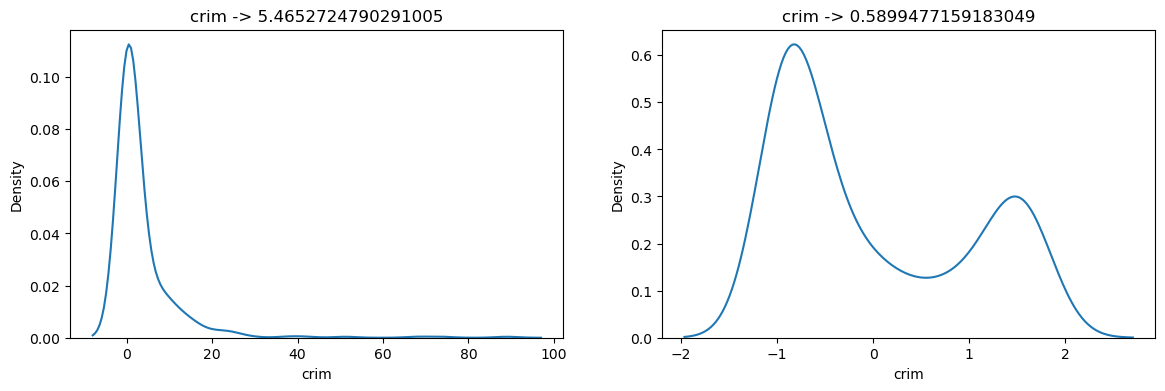

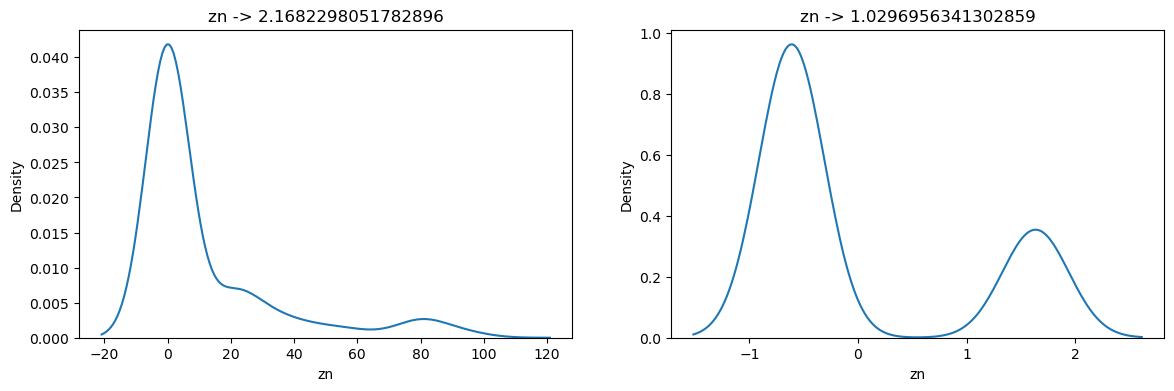

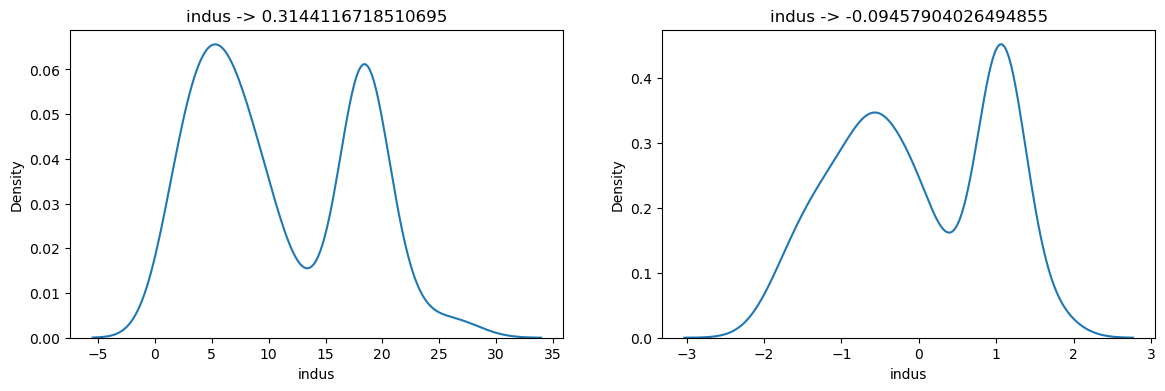

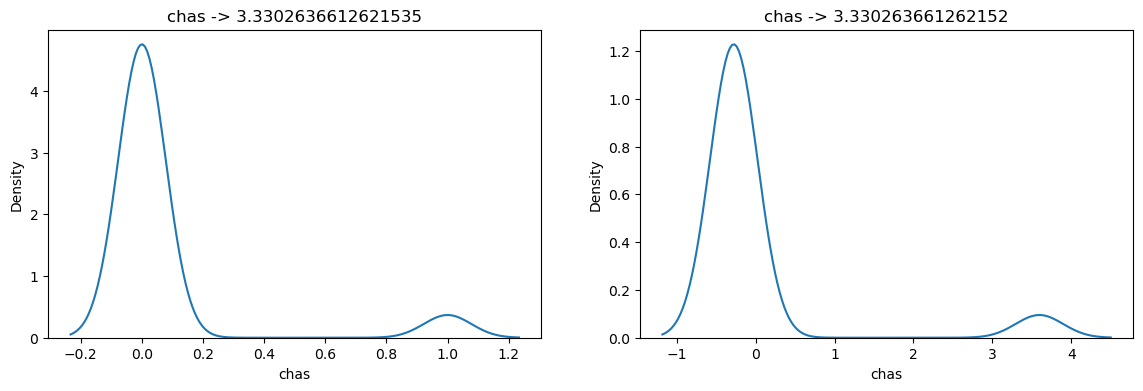

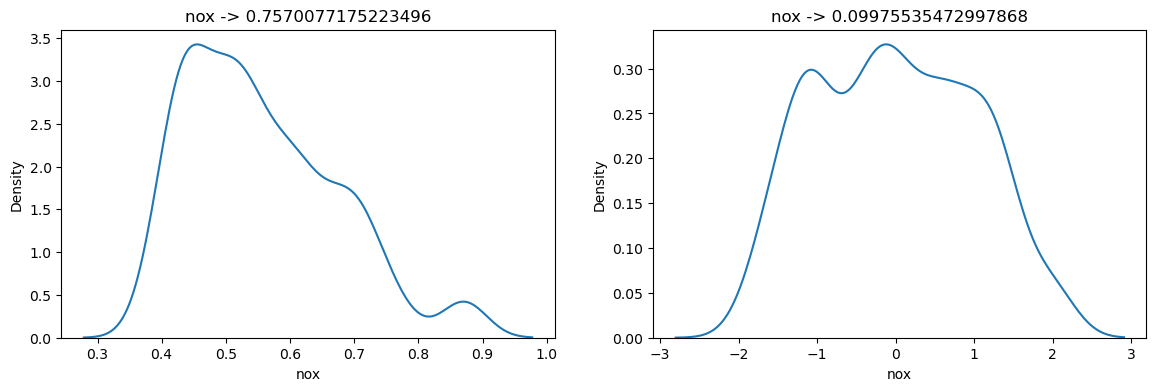

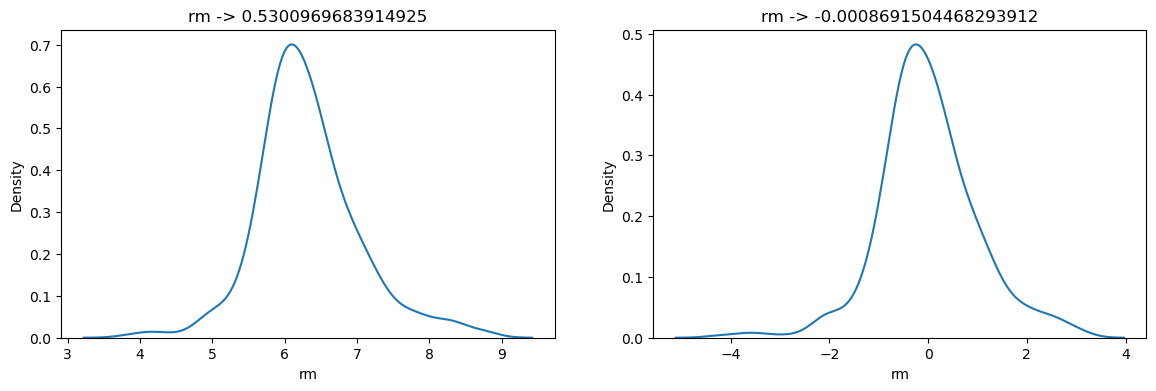

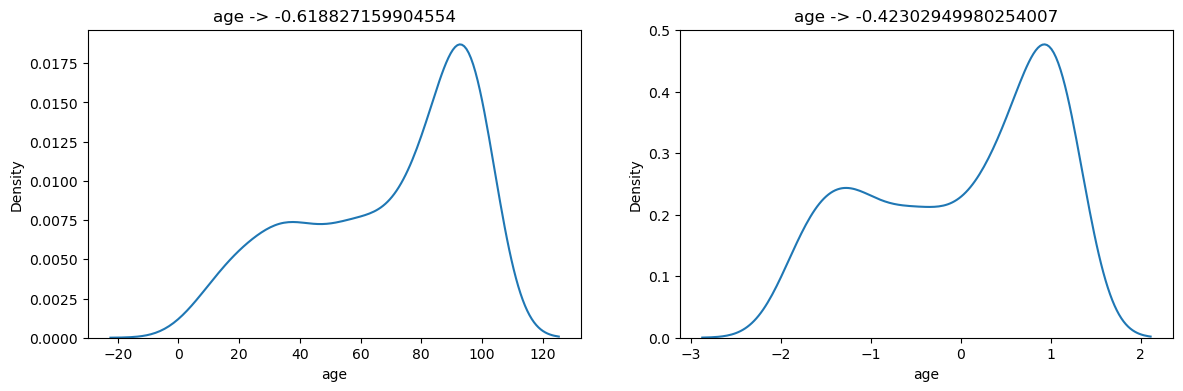

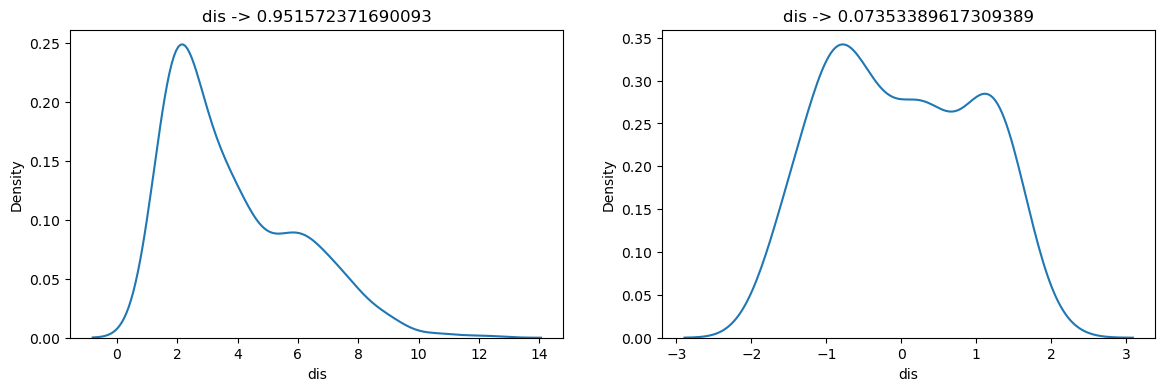

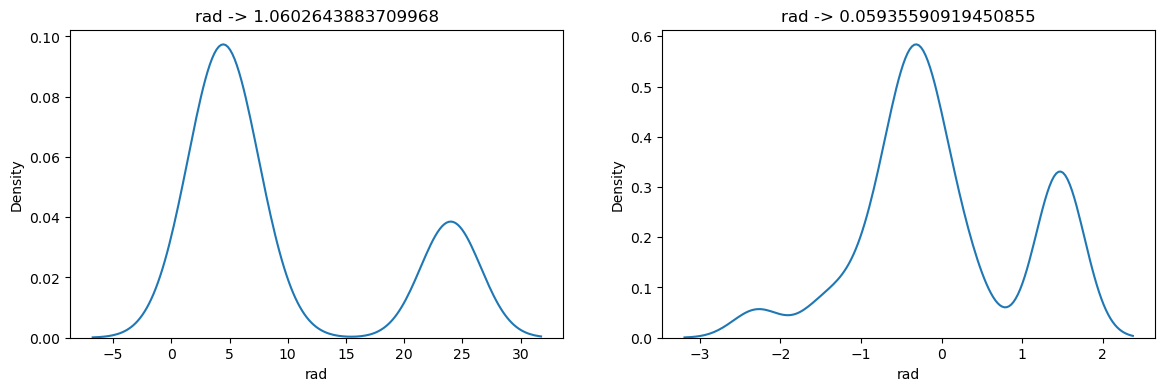

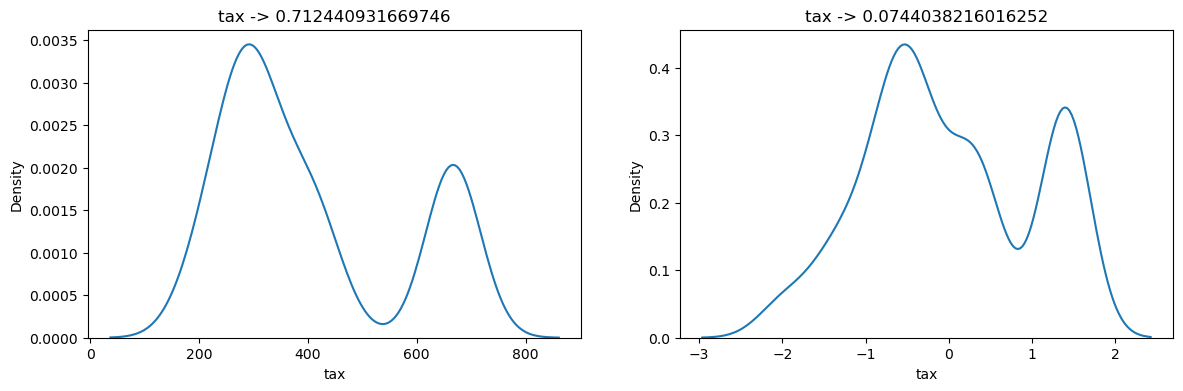

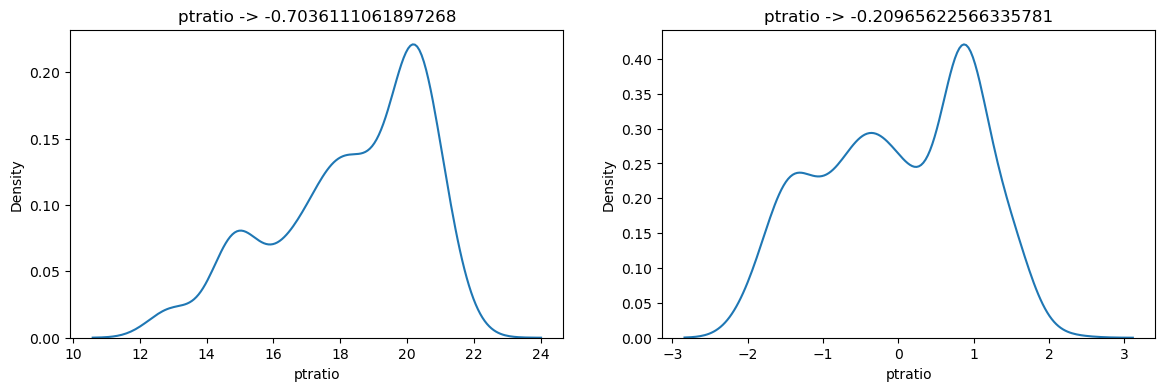

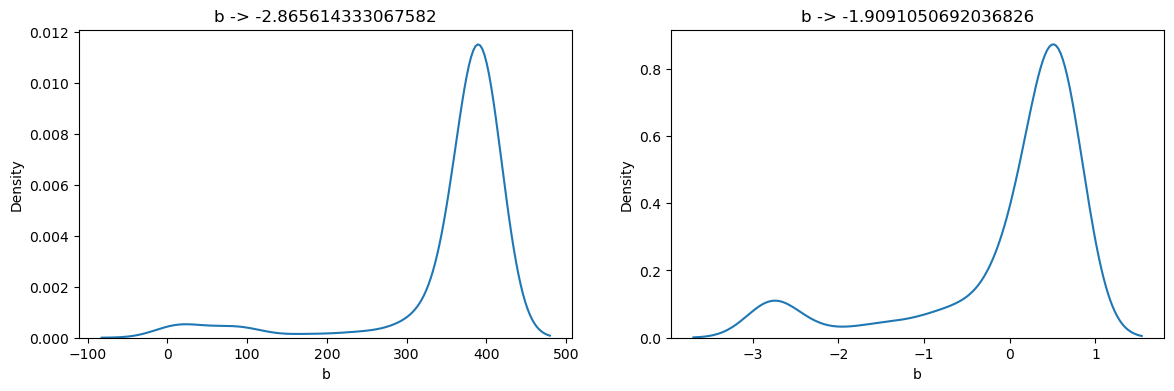

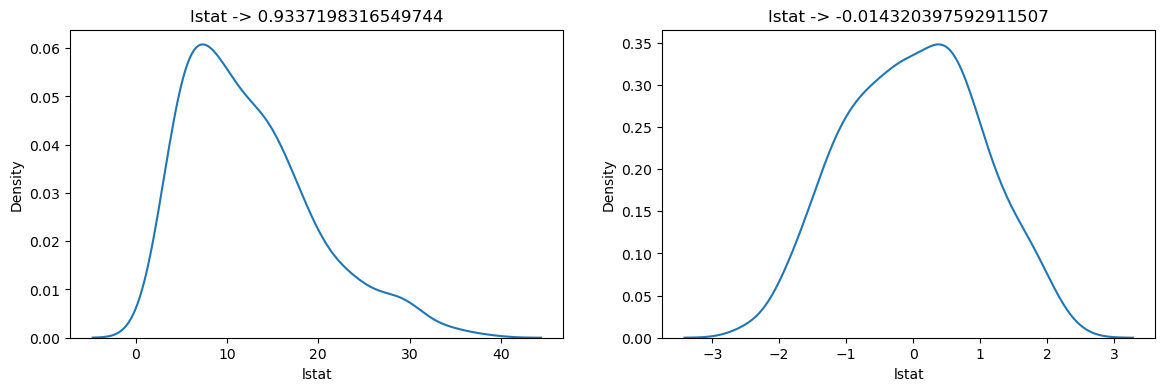

In [39]:
# Before and after comparision for Box-Cox Plot
X_train_transformed2 = pd.DataFrame(X_train_transformed2 ,columns=X_train.columns)

for col in X_train_transformed2.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.kdeplot(X_train[col])
    txt = col + " -> " + str(X_train[col].skew())
    plt.title(txt)

    plt.subplot(122)
    sns.kdeplot(X_train_transformed2[col])
    txt1 = col + " -> " + str(X_train_transformed2[col].skew())
    plt.title(txt1)

    plt.show()

In [40]:
# Side by side Lambdas
pd.DataFrame({'cols':X_train.columns,'box_cox_lambdas':pt.lambdas_,'Yeo_Johnson_lambdas':pt1.lambdas_})

,cols,box_cox_lambdas,Yeo_Johnson_lambdas
0,crim,-0.114374,-0.958995
1,zn,-0.181510,-0.867045
2,indus,0.389192,0.332416
3,chas,-1.008349,-20.097985
4,nox,-0.938023,-4.033137
5,rm,0.147907,-0.014434
6,age,1.362922,1.388267
7,dis,-0.165778,-0.459648
8,rad,-0.134975,-0.367935
9,tax,-0.526450,-0.530211
